In [2]:
import os
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import lxml

In [3]:
file_path = r'C:\Users\isaac\Downloads\usa_00003.csv.gz'
df = pd.read_csv(file_path, compression='gzip')

In [16]:
for col in df.select_dtypes(include=[np.number]).columns:
    df.loc[(df[col] == 9999999) | (df[col] < 0), col] = np.nan

if 'EDUCYR' in df.columns:
    df['EDUCYR'] = df['EDUCYR'] + 2

print("Data cleaning complete.")

Data cleaning complete.


In [17]:
# Clean FAMSIZE: replace 0 or negative with NaN
df.loc[df['FAMSIZE'] <= 0, 'FAMSIZE'] = np.nan

# Clean SEX: keep only 1 or 2, else NaN
df.loc[~df['SEX'].isin([1, 2]), 'SEX'] = np.nan

# Clean MARST: replace invalid codes <=0 or > expected max (assume max 6) with NaN
df.loc[(df['MARST'] <= 0) | (df['MARST'] > 6), 'MARST'] = np.nan

# Clean RACE: replace codes <=0 or >9 with NaN (assuming max race code 9)
df.loc[(df['RACE'] <= 0) | (df['RACE'] > 9), 'RACE'] = np.nan

# Clean UHRSWORK: replace values <=0 or >100 with NaN
df.loc[(df['UHRSWORK'] <= 0) | (df['UHRSWORK'] > 100), 'UHRSWORK'] = np.nan

# Clean HHINCOME: replace negative with NaN
df.loc[df['HHINCOME'] < 0, 'HHINCOME'] = np.nan

# Clean EMPSTAT: replace invalid codes <=0 or >7 with NaN (assuming max 7)
df.loc[(df['EMPSTAT'] <= 0) | (df['EMPSTAT'] > 7), 'EMPSTAT'] = np.nan

print("Additional data cleaning complete.")

Additional data cleaning complete.


In [18]:
# See the first few rows to confirm the data looks correct
print(df.head())

# Show general info about each column (type, missing values, etc.)
print(df.info())

# Summary statistics for numeric variables
print(df.describe())

     YEAR    SAMPLE  SERIAL      CBSERIAL  HHWT  HHTYPE       CLUSTER  \
0  2023.0  202301.0     1.0  2.023010e+12   6.0     0.0  2.023000e+12   
1  2023.0  202301.0     2.0  2.023010e+12  27.0     0.0  2.023000e+12   
2  2023.0  202301.0     3.0  2.023010e+12  47.0     0.0  2.023000e+12   
3  2023.0  202301.0     4.0  2.023010e+12  11.0     0.0  2.023000e+12   
4  2023.0  202301.0     5.0  2.023010e+12  57.0     0.0  2.023000e+12   

     STRATA   GQ  HHINCOME  ...  MARST  RACE  RACED  EDUC  EDUCD  EMPSTAT  \
0  280201.0  3.0       NaN  ...    5.0   2.0  200.0   6.0   63.0      3.0   
1   10001.0  3.0       NaN  ...    6.0   1.0  100.0   6.0   63.0      3.0   
2   40201.0  4.0       NaN  ...    6.0   1.0  100.0   7.0   71.0      3.0   
3  270201.0  3.0       NaN  ...    6.0   2.0  200.0   2.0   26.0      NaN   
4  280201.0  4.0       NaN  ...    6.0   1.0  100.0   6.0   65.0      3.0   

   EMPSTATD  CLASSWKR  CLASSWKRD  UHRSWORK  
0      30.0       0.0        0.0       NaN  
1      3

In [19]:
# Count missing (NaN) values in each column
print(df.isna().sum())

YEAR               0
SAMPLE             0
SERIAL             0
CBSERIAL           0
HHWT               0
HHTYPE             0
CLUSTER            0
STRATA             0
GQ                 0
HHINCOME      177101
PERNUM             0
PERWT              0
FAMSIZE            0
SEX                0
AGE                0
MARST              0
RACE               0
RACED              0
EDUC               0
EDUCD              0
EMPSTAT       558164
EMPSTATD           0
CLASSWKR           0
CLASSWKRD          0
UHRSWORK     1646849
dtype: int64


In [20]:
# Maximum and minimum for continuous variables
print("HHINCOME min/max:", df['HHINCOME'].min(), "/", df['HHINCOME'].max())
print("UHRSWORK min/max:", df['UHRSWORK'].min(), "/", df['UHRSWORK'].max())
print("FAMSIZE min/max:", df['FAMSIZE'].min(), "/", df['FAMSIZE'].max())

HHINCOME min/max: 0.0 / 3002000.0
UHRSWORK min/max: 1.0 / 99.0
FAMSIZE min/max: 1.0 / 20.0


In [21]:
# Count duplicate rows (if any)
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [22]:
# Optional: Replace missing numeric values with NaN for clarity
df = df.replace({9999999: np.nan, 999999: np.nan, 99999: np.nan})

# Optional: Save cleaned dataset for later
df.to_csv(r'C:\Users\isaac\Downloads\usa_00003_cleaned.csv', index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [5]:
df = pd.read_csv(r'C:\Users\isaac\Downloads\usa_00003_cleaned.csv')

In [6]:
print("Detailed Descriptive Stats for Key Variables:\n")
print(df[['HHINCOME', 'FAMSIZE']].describe(include='all'))

print("\nSkewness:")
print(df[['HHINCOME', 'FAMSIZE']].skew())

print("\nKurtosis:")
print(df[['HHINCOME', 'FAMSIZE']].kurt())

print("\nBasic Descriptive Stats for All Variables:\n")
print(df.describe())

print("\nMean values for all numeric variables:")
print(df.mean(numeric_only=True))

print("\nMissing values per variable:")
print(df.isnull().sum())

Detailed Descriptive Stats for Key Variables:

           HHINCOME       FAMSIZE
count  3.228708e+06  3.405809e+06
mean   1.287257e+05  2.995439e+00
std    1.306477e+05  1.722640e+00
min    0.000000e+00  1.000000e+00
25%    5.164000e+04  2.000000e+00
50%    9.560000e+04  3.000000e+00
75%    1.600000e+05  4.000000e+00
max    3.002000e+06  2.000000e+01

Skewness:
HHINCOME    3.420702
FAMSIZE     1.183246
dtype: float64

Kurtosis:
HHINCOME    19.904416
FAMSIZE      2.502928
dtype: float64

Basic Descriptive Stats for All Variables:

            YEAR     SAMPLE        SERIAL      CBSERIAL          HHWT  \
count  3405809.0  3405809.0  3.405805e+06  3.405809e+06  3.405809e+06   
mean      2023.0   202301.0  7.589920e+05  2.023001e+12  9.723818e+01   
std          0.0        0.0  4.414735e+05  2.111813e+06  8.743515e+01   
min       2023.0   202301.0  1.000000e+00  2.023000e+12  1.000000e+00   
25%       2023.0   202301.0  3.723860e+05  2.023000e+12  4.800000e+01   
50%       2023.0   202301.

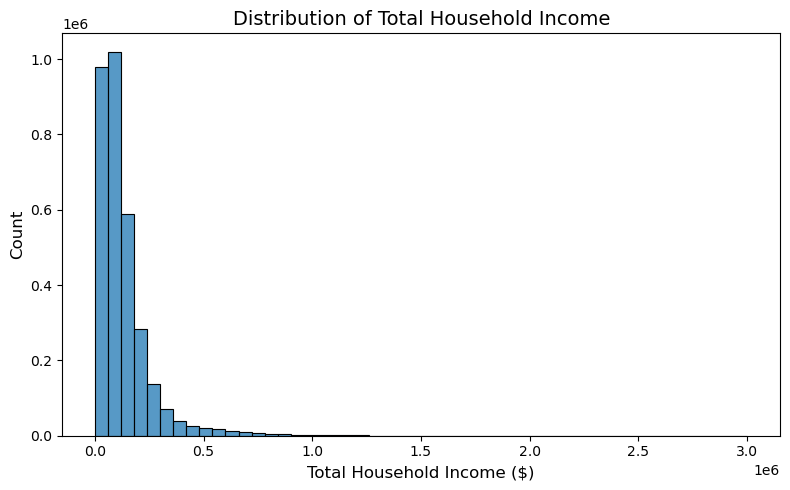

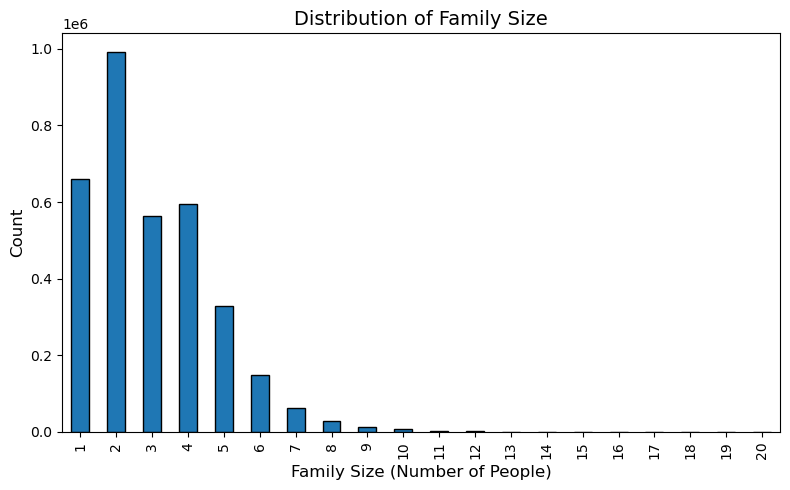

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.histplot(df['HHINCOME'].dropna(), bins=50, edgecolor='black')
plt.title('Distribution of Total Household Income', fontsize=14)
plt.xlabel('Total Household Income ($)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

# ----------------------------
# Bar Plot for Family Size (Treatment Variable)
# ----------------------------
plt.figure(figsize=(8, 5))
df['FAMSIZE'].dropna().astype(int).value_counts().sort_index().plot(
    kind='bar', edgecolor='black'
)
plt.title('Distribution of Family Size', fontsize=14)
plt.xlabel('Family Size (Number of People)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

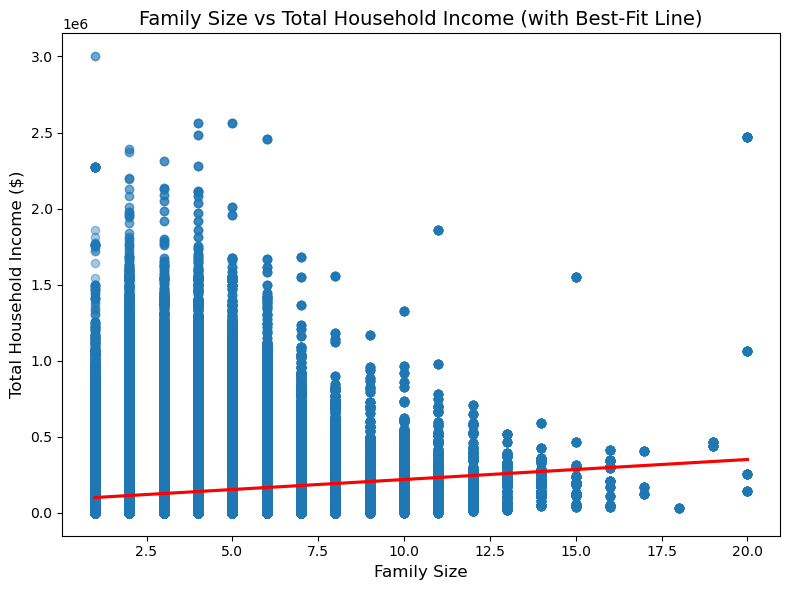

In [8]:
plt.figure(figsize=(8, 6))

sns.regplot(
    x='FAMSIZE', 
    y='HHINCOME', 
    data=df, 
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
)

plt.title('Family Size vs Total Household Income (with Best-Fit Line)', fontsize=14)
plt.xlabel('Family Size', fontsize=12)
plt.ylabel('Total Household Income ($)', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
# Drop missing values for the two variables
sub = df[['FAMSIZE', 'HHINCOME']].dropna()

# Find the median family size
median_famsize = sub['FAMSIZE'].median()
print("Median family size:", median_famsize)

# Create grouping variable: low vs high family size
sub['FAMSIZE_GROUP'] = np.where(sub['FAMSIZE'] <= median_famsize, 'Low family size', 'High family size')

# Quick check of group sizes
print(sub['FAMSIZE_GROUP'].value_counts())

Median family size: 3.0
FAMSIZE_GROUP
Low family size     2037451
High family size    1191257
Name: count, dtype: int64


In [10]:
import statsmodels.formula.api as smf

# Keep only variables we need and drop missing
reg_df = df[['HHINCOME', 'FAMSIZE', 'SEX', 'MARST', 'RACE', 
             'EDUCD', 'EMPSTAT', 'CLASSWKR', 'UHRSWORK', 'AGE', 'YEAR']].dropna()

# Optional: sample to make regression faster
reg_df = reg_df.sample(n=100000, random_state=1)

# Full model formula including all requested variables
full_formula = """
HHINCOME ~ FAMSIZE
           + AGE
           + UHRSWORK
           + C(SEX)
           + C(MARST)
           + C(RACE)
           + C(EDUCD)
           + C(EMPSTAT)
           + C(CLASSWKR)
"""
# Fit the full regression model
full_model = smf.ols(full_formula, data=reg_df).fit()
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:               HHINCOME   R-squared:                       0.167
Model:                            OLS   Adj. R-squared:                  0.167
Method:                 Least Squares   F-statistic:                     466.3
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        14:28:49   Log-Likelihood:            -1.3138e+06
No. Observations:              100000   AIC:                         2.628e+06
Df Residuals:                   99956   BIC:                         2.628e+06
Df Model:                          43                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           1.368e+04   4469

In [11]:
import statsmodels.formula.api as smf

reg_df = df[['HHINCOME', 'FAMSIZE', 'SEX', 'MARST', 'RACE',
             'EDUCD', 'EMPSTAT', 'CLASSWKR', 'UHRSWORK', 'AGE']].dropna()

reg_df = reg_df.sample(n=100000, random_state=1)

refined_formula = """
HHINCOME ~ FAMSIZE
           + AGE
           + UHRSWORK
           + C(SEX)
           + C(MARST)
           + C(RACE)
           + C(EDUCD)
           + C(EMPSTAT)
           + C(CLASSWKR)
"""
refined_model = smf.ols(refined_formula, data=reg_df).fit()
print(refined_model.summary())

                            OLS Regression Results                            
Dep. Variable:               HHINCOME   R-squared:                       0.167
Model:                            OLS   Adj. R-squared:                  0.167
Method:                 Least Squares   F-statistic:                     466.3
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        14:32:42   Log-Likelihood:            -1.3138e+06
No. Observations:              100000   AIC:                         2.628e+06
Df Residuals:                   99956   BIC:                         2.628e+06
Df Model:                          43                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           1.368e+04   4469

In [12]:
df = pd.read_csv(r"C:\Users\isaac\Downloads\usa_00003_cleaned.csv")

# Select variables and drop rows with missing values
clean_df = df[['SEX', 'MARST', 'RACE', 'EMPSTAT']].dropna()

# --- Recode SEX into Male / Female ---
sex_map = {
    1: "Male",
    2: "Female"
}
clean_df["SEX_label"] = clean_df["SEX"].map(sex_map)

# --- Recode MARST into full descriptive labels ---
marst_map = {
    1: "Married, spouse present",
    2: "Married, spouse absent",
    3: "Separated",
    4: "Divorced",
    5: "Widowed",
    6: "Never married/single"
}
clean_df["MARST_label"] = clean_df["MARST"].map(marst_map)

# --- Recode RACE into White vs Non-White ---
clean_df["RACE_binary"] = clean_df["RACE"].apply(lambda x: "White" if x == 1 else "Non-White")

# --- Recode EMPSTAT into Employed vs Not employed ---
clean_df["EMP_binary"] = clean_df["EMPSTAT"].apply(lambda x: "Employed" if x == 1 else "Not employed")

# --- Print value counts with labels ---
print("SEX (labeled) counts:")
print(clean_df["SEX_label"].value_counts(), "\n")

print("MARST (labeled) counts:")
print(clean_df["MARST_label"].value_counts(), "\n")

print("RACE_binary counts:")
print(clean_df["RACE_binary"].value_counts(), "\n")

print("EMP_binary counts:")
print(clean_df["EMP_binary"].value_counts(), "\n")

SEX (labeled) counts:
SEX_label
Female    1462225
Male      1385420
Name: count, dtype: int64 

MARST (labeled) counts:
MARST_label
Married, spouse present    1402121
Never married/single        844439
Divorced                    305308
Widowed                     189318
Married, spouse absent       65575
Separated                    40884
Name: count, dtype: int64 

RACE_binary counts:
RACE_binary
White        1943664
Non-White     903981
Name: count, dtype: int64 

EMP_binary counts:
EMP_binary
Employed        1598838
Not employed    1248807
Name: count, dtype: int64 



In [14]:
# Choose your continuous variables
cont_vars = ['HHINCOME', 'FAMSIZE', 'AGE', 'UHRSWORK']

# Create a summary table in the "N / Mean / Median / Std. Dev / Min / Max" format
rows = ['N (Sample Size)', 'Mean', 'Median', 'Std. Dev.', 'Minimum', 'Maximum']
table1 = pd.DataFrame(index=rows)

for var in cont_vars:
    s = df[var].dropna()
    table1[var] = [
        int(s.count()),          # N
        s.mean(),                # Mean
        s.median(),              # Median
        s.std(),                 # Std. Dev.
        s.min(),                 # Min
        s.max()                  # Max
    ]

# Optional: rename columns to nice labels for the poster
table1 = table1.rename(columns={
    'HHINCOME': 'Total Household Income ($)',
    'FAMSIZE': 'Family Size',
    'AGE': 'Age',
    'UHRSWORK': 'Hours Worked / Week'
})

print("Table 1: Descriptive Statistics for Continuous Variables\n")
print(table1.round(2))   # round for nicer display

# Make sure clean_df exists and has these labeled columns:
# SEX_label, MARST_label, RACE_binary, EMP_binary

cat_vars = {
    'SEX_label': 'Sex',
    'MARST_label': 'Marital Status',
    'RACE_binary': 'Race (White / Non-White)',
    'EMP_binary': 'Employment Status'
}

rows = []

for col, label in cat_vars.items():
    # Total non-missing for this variable
    total = clean_df[col].notna().sum()
    
    # Header row like "-- Sex --"
    rows.append({
        "Category": f"-- {label} --",
        "Percentage": ""
    })
    
    # Percentages for each category
    vc = clean_df[col].value_counts(normalize=True) * 100
    for cat, pct in vc.items():
        rows.append({
            "Category": f"  {cat}",
            "Percentage": f"{pct:.1f}%"   # one decimal, like 52.9%
        })

table2 = pd.DataFrame(rows)

print("Table 2: Frequency Table for Categorical Variables\n")
print(table2)

Table 1: Descriptive Statistics for Continuous Variables

                 Total Household Income ($)  Family Size         Age  \
N (Sample Size)                  3228708.00   3405809.00  3405809.00   
Mean                              128725.74         3.00       43.11   
Median                             95600.00         3.00       44.00   
Std. Dev.                         130647.68         1.72       23.97   
Minimum                                0.00         1.00        0.00   
Maximum                          3002000.00        20.00       96.00   

                 Hours Worked / Week  
N (Sample Size)           1758960.00  
Mean                           37.69  
Median                         40.00  
Std. Dev.                      13.16  
Minimum                         1.00  
Maximum                        99.00  
Table 2: Frequency Table for Categorical Variables

                          Category Percentage
0                        -- Sex --           
1                   

In [17]:
from scipy.stats import ttest_ind

# Check median family size
median_famsize = df['FAMSIZE'].median()
print("Median family size:", median_famsize)

# Split into low vs high family size groups
low_fam = df.loc[df['FAMSIZE'] < median_famsize, 'HHINCOME'].dropna()
high_fam = df.loc[df['FAMSIZE'] >= median_famsize, 'HHINCOME'].dropna()

# Two-sample t-test (Welch's t-test)
t_stat, p_value = ttest_ind(high_fam, low_fam, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

print("\nMean HHINCOME (Low family size):", low_fam.mean())
print("Mean HHINCOME (High family size):", high_fam.mean())

Median family size: 3.0
T-statistic: 330.3051139756832
P-value: 0.0

Mean HHINCOME (Low family size): 103350.23458510709
Mean HHINCOME (High family size): 150036.55938152812


In [18]:
# Median family size
median_famsize = df['FAMSIZE'].median()

# Define groups
low_fam = df.loc[df['FAMSIZE'] < median_famsize, 'HHINCOME'].dropna()
high_fam = df.loc[df['FAMSIZE'] >= median_famsize, 'HHINCOME'].dropna()

# Sample sizes
n_low = low_fam.shape[0]
n_high = high_fam.shape[0]

print("Sample size (Low family size):", n_low)
print("Sample size (High family size):", n_high)

Sample size (Low family size): 1473802
Sample size (High family size): 1754906


In [22]:
import pandas as pd
import numpy as np

def stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

def make_poster_reg_table(model, keep=None, title="Multiple Regression Results"):
    # Grab coefficient table from model
    out = pd.DataFrame({
        "Variable": model.params.index,
        "Coef.": model.params.values,
        "Std. Err.": model.bse.values,
        "p-value": model.pvalues.values
    })

    # Add significance stars and formatted strings
    out["Sig."] = out["p-value"].apply(stars)
    out["Coef. (SE)"] = out.apply(lambda r: f"{r['Coef.']:.2f}{r['Sig.']} ({r['Std. Err.']:.2f})", axis=1)

    # Keep only selected rows (recommended for posters)
    if keep is not None:
        out = out[out["Variable"].isin(keep)]

    # Final pretty table
    table = out[["Variable", "Coef. (SE)", "p-value"]].copy()
    table["p-value"] = table["p-value"].map(lambda x: f"{x:.4g}")

    # Add model stats as footer rows
    footer = pd.DataFrame({
        "Variable": ["N", "Adj. R-squared"],
        "Coef. (SE)": [f"{int(model.nobs)}", f"{model.rsquared_adj:.3f}"],
        "p-value": ["", ""]
    })

    table = pd.concat([table, footer], ignore_index=True)

    print(title)
    return table

# ---- Example usage ----
# Choose which rows to show (poster-friendly)
keep_vars = [
    "Intercept",
    "FAMSIZE",
    "AGE",
    "UHRSWORK",
    "C(SEX)[T.2.0]",
    "C(RACE)[T.2.0]",
    "C(CLASSWKR)[T.2.0]"
]

reg_table = make_poster_reg_table(refined_model, keep=keep_vars,
                                  title="Multiple Regression Results (Poster Format)")

print(reg_table)

Multiple Regression Results (Poster Format)
             Variable              Coef. (SE)    p-value
0           Intercept    13684.87** (4469.62)   0.002201
1       C(SEX)[T.2.0]    -6029.92*** (803.20)  6.081e-14
2      C(RACE)[T.2.0]  -24467.59*** (1489.40)  1.453e-60
3  C(CLASSWKR)[T.2.0]   -4556.58*** (1269.09)  0.0003303
4             FAMSIZE    15061.21*** (274.68)          0
5                 AGE       471.46*** (32.61)    2.5e-47
6            UHRSWORK       959.34*** (32.03)  2.91e-196
7                   N                  100000           
8      Adj. R-squared                   0.167           


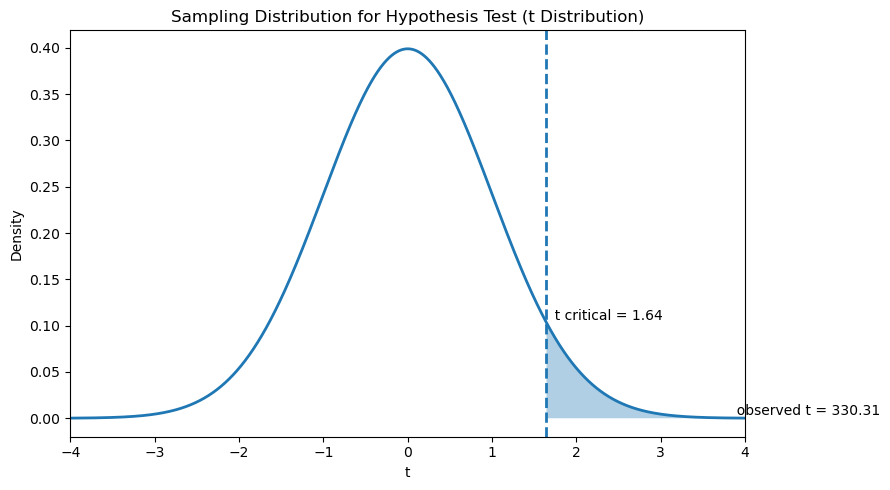

Observed t-stat: 330.305113975664
Welch df: 3228180.752510105
Critical t (right-tailed, alpha=0.05): 1.644854098972621


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# ---- Recreate the same low/high groups you used ----
median_famsize = df['FAMSIZE'].median()

low_fam  = df.loc[df['FAMSIZE'] <  median_famsize, 'HHINCOME'].dropna()
high_fam = df.loc[df['FAMSIZE'] >= median_famsize, 'HHINCOME'].dropna()

# ---- Welch's t-test components (to get df for the t distribution) ----
n1, n2 = low_fam.shape[0], high_fam.shape[0]
s1, s2 = low_fam.var(ddof=1), high_fam.var(ddof=1)

# observed t-statistic (match your previous direction: high - low)
t_stat = (high_fam.mean() - low_fam.mean()) / np.sqrt(s1/n1 + s2/n2)

# Welch–Satterthwaite degrees of freedom
df_welch = (s1/n1 + s2/n2)**2 / ((s1**2)/((n1**2)*(n1-1)) + (s2**2)/((n2**2)*(n2-1)))

alpha = 0.05  # 5% significance level
t_crit = t.ppf(1 - alpha, df_welch)  # right-tailed critical value

# ---- Plot the sampling distribution (t distribution) ----
x = np.linspace(-4, 4, 2000)
y = t.pdf(x, df_welch)

plt.figure(figsize=(9, 5))
plt.plot(x, y, linewidth=2)

# Shade rejection region (right tail)
x_reject = np.linspace(t_crit, 4, 500)
plt.fill_between(x_reject, t.pdf(x_reject, df_welch), alpha=0.35)

# Mark critical value and observed t
plt.axvline(t_crit, linestyle='--', linewidth=2)
plt.axvline(t_stat, linestyle='-', linewidth=2)

plt.title("Sampling Distribution for Hypothesis Test (t Distribution)")
plt.xlabel("t")
plt.ylabel("Density")

plt.text(t_crit, t.pdf(t_crit, df_welch), f"  t critical = {t_crit:.2f}", va='bottom')
plt.text(min(t_stat, 3.8), t.pdf(min(t_stat, 3.8), df_welch), f"  observed t = {t_stat:.2f}", va='bottom')

plt.xlim(-4, 4)
plt.tight_layout()
plt.show()

print("Observed t-stat:", t_stat)
print("Welch df:", df_welch)
print("Critical t (right-tailed, alpha=0.05):", t_crit)

In [28]:
import pandas as pd

# Select only the variables used in the project
vars_for_table = ['HHINCOME', 'FAMSIZE', 'AGE', 'UHRSWORK']

# Build the table
table1 = df[vars_for_table].describe().loc[
    ['count', 'mean', '50%', 'std', 'min', 'max']
]

# Rename rows to match example formatting
table1 = table1.rename(index={
    'count': 'N',
    'mean': 'Mean',
    '50%': 'Median',
    'std': 'Std. Dev.',
    'min': 'Minimum',
    'max': 'Maximum'
})

# Rename columns to readable labels
table1 = table1.rename(columns={
    'HHINCOME': 'Total Household Income ($)',
    'FAMSIZE': 'Family Size',
    'AGE': 'Age',
    'UHRSWORK': 'Hours Worked / Week'
})

# Round for clean presentation
table1 = table1.round(2)

print("Table 1: Descriptive Statistics for Continuous Variables")
print(table1)

Table 1: Descriptive Statistics for Continuous Variables
           Total Household Income ($)  Family Size         Age  \
N                          3228708.00   3405809.00  3405809.00   
Mean                        128725.74         3.00       43.11   
Median                       95600.00         3.00       44.00   
Std. Dev.                   130647.68         1.72       23.97   
Minimum                          0.00         1.00        0.00   
Maximum                    3002000.00        20.00       96.00   

           Hours Worked / Week  
N                   1758960.00  
Mean                     37.69  
Median                   40.00  
Std. Dev.                13.16  
Minimum                   1.00  
Maximum                  99.00  
